# Crown Tracking: Shift Alignment Experiments

This notebook mirrors the data discovery and crown loading flow from the main tracking notebook, but focuses **only on alignment**. It compares multiple alignment strategies:

1. **Current approach**: crown centroid mutual NN shift
2. **Phase correlation** on orthomosaic image features
3. **ORB keypoints + RANSAC** on orthomosaic image features

The outputs include a shift table and visual overlays (crown boundaries and orthomosaic image overlays) to help you decide which method looks best.

In [21]:
import os
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import Affine
from shapely.affinity import translate
from sklearn.neighbors import NearestNeighbors

SKIMAGE_AVAILABLE = True
try:
    from skimage.registration import phase_cross_correlation
    from skimage.feature import ORB, match_descriptors
    from skimage.measure import ransac
    from skimage.transform import SimilarityTransform, warp, resize
    from skimage.filters import sobel
except Exception as e:
    SKIMAGE_AVAILABLE = False
    print("⚠️ scikit-image not available. Phase correlation and ORB alignment will be skipped.")
    print(str(e))

In [2]:
# ---- Configuration ----
ROOT_DIR = Path(os.getcwd())
CROWN_DIR_CANDIDATES = [ROOT_DIR / 'input/input_crowns', ROOT_DIR / '../../input/input_crowns']
ORTHO_DIR_CANDIDATES = [ROOT_DIR / 'input/input_om', ROOT_DIR / '../../input/input_om']

REFERENCE_OM_ID = None  # set to an int if you want a fixed reference
MAX_PREVIEW_SIZE = 1200  # max width/height for low-res ortho previews
CENTROID_THRESHOLD = 20.0
CENTROID_MIN_MATCHES = 5

In [3]:
def resolve_dir(candidates: List[Path]) -> Path:
    for p in candidates:
        if p.exists() and p.is_dir():
            return p.resolve()
    raise FileNotFoundError(f"Could not resolve directory from: {candidates}")

def extract_numeric_id(name: str) -> Optional[int]:
    m = re.search(r"(\d+)", os.path.basename(name))
    return int(m.group(1)) if m else None

def discover_pairs(crown_dir: Path, ortho_dir: Path) -> Tuple[List[Tuple[str, Optional[str]]], List[int]]:
    crown_files = [str(crown_dir / f) for f in os.listdir(crown_dir) if f.lower().endswith('.gpkg')]
    ortho_files = [str(ortho_dir / f) for f in os.listdir(ortho_dir) if f.lower().endswith('.tif')] if ortho_dir.exists() else []

    if not crown_files:
        raise FileNotFoundError(f"No .gpkg crown files found in {crown_dir}")

    crowns_by_id = {}
    for cf in crown_files:
        cid = extract_numeric_id(cf)
        crowns_by_id[cid if cid is not None else cf] = cf

    orthos_by_id = {}
    for of in ortho_files:
        oid = extract_numeric_id(of)
        orthos_by_id[oid if oid is not None else of] = of

    numeric_ids = sorted(
        set(k for k in crowns_by_id.keys() if isinstance(k, int)) &
        set(k for k in orthos_by_id.keys() if isinstance(k, int))
    )

    file_pairs: List[Tuple[str, Optional[str]]] = []
    if numeric_ids:
        for nid in numeric_ids:
            file_pairs.append((crowns_by_id[nid], orthos_by_id.get(nid)))
        crown_only = sorted(k for k in crowns_by_id.keys() if isinstance(k, int) and k not in numeric_ids)
        for nid in crown_only:
            file_pairs.append((crowns_by_id[nid], None))
    else:
        crown_files_sorted = sorted(crown_files)
        ortho_files_sorted = sorted(ortho_files)
        for i, cf in enumerate(crown_files_sorted):
            of = ortho_files_sorted[i] if i < len(ortho_files_sorted) else None
            file_pairs.append((cf, of))

    om_ids: List[int] = []
    for cf, _ in file_pairs:
        cid = extract_numeric_id(cf)
        om_ids.append(cid if cid is not None else len(om_ids) + 1)

    pairs_with_id = sorted(
        [(oid, cf, of) for oid, (cf, of) in zip(om_ids, file_pairs)],
        key=lambda x: x[0],
    )
    sorted_pairs = [(cf, of) for _, cf, of in pairs_with_id]
    sorted_ids = [oid for oid, _, _ in pairs_with_id]
    return sorted_pairs, sorted_ids

crown_dir = resolve_dir(CROWN_DIR_CANDIDATES)
ortho_dir = resolve_dir(ORTHO_DIR_CANDIDATES)
file_pairs, om_ids = discover_pairs(crown_dir, ortho_dir)
print(f"Found {len(file_pairs)} crown files")
print("OM IDs:", om_ids)

Found 5 crown files
OM IDs: [1, 2, 3, 4, 5]


In [16]:
def read_ortho_lowres(path: str, max_size: int = 1200):
    with rasterio.open(path) as src:
        scale = max(src.width, src.height) / max_size if max(src.width, src.height) > max_size else 1.0
        out_w = int(round(src.width / scale))
        out_h = int(round(src.height / scale))
        data = src.read([1, 2, 3], out_shape=(3, out_h, out_w), resampling=Resampling.bilinear)
        rgb = np.moveaxis(data, 0, -1).astype(np.float32)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
        gray = 0.2989 * rgb[..., 0] + 0.5870 * rgb[..., 1] + 0.1140 * rgb[..., 2]
        scale_x = src.width / out_w
        scale_y = src.height / out_h
        transform = src.transform * Affine.scale(scale_x, scale_y)
        return rgb, gray, transform

def _bounds_from_transform(h: int, w: int, transform: Affine) -> Tuple[float, float, float, float]:
    corners = [(0, 0), (0, w), (h, 0), (h, w)]
    xs = []
    ys = []
    for row, col in corners:
        x, y = rasterio.transform.xy(transform, row, col, offset='ul')
        xs.append(x)
        ys.append(y)
    left, right = min(xs), max(xs)
    bottom, top = min(ys), max(ys)
    return left, bottom, right, top

# Load crowns + low-res orthos
crowns_gdfs: Dict[int, gpd.GeoDataFrame] = {}
ortho_rgb: Dict[int, Optional[np.ndarray]] = {}
ortho_gray: Dict[int, Optional[np.ndarray]] = {}
ortho_transform: Dict[int, Optional[Affine]] = {}

for om_id, (crown_file, ortho_file) in zip(om_ids, file_pairs):
    gdf = gpd.read_file(crown_file)
    crowns_gdfs[om_id] = gdf
    if ortho_file and os.path.exists(ortho_file):
        rgb, gray, transform = read_ortho_lowres(ortho_file, MAX_PREVIEW_SIZE)
        ortho_rgb[om_id] = rgb
        ortho_gray[om_id] = gray
        ortho_transform[om_id] = transform
    else:
        ortho_rgb[om_id] = None
        ortho_gray[om_id] = None
        ortho_transform[om_id] = None

# Compute common overlap bounds across all orthos (features present in all)
valid_bounds = []
for om_id in om_ids:
    gray = ortho_gray.get(om_id)
    transform = ortho_transform.get(om_id)
    if gray is None or transform is None:
        continue
    h, w = gray.shape[:2]
    left, bottom, right, top = _bounds_from_transform(h, w, transform)
    valid_bounds.append((left, bottom, right, top))

GLOBAL_COMMON_BOUNDS = None
if valid_bounds:
    lefts, bottoms, rights, tops = zip(*valid_bounds)
    left = max(lefts)
    bottom = max(bottoms)
    right = min(rights)
    top = min(tops)
    if left < right and bottom < top:
        GLOBAL_COMMON_BOUNDS = (left, bottom, right, top)
        print(f"Common overlap bounds: {GLOBAL_COMMON_BOUNDS}")
    else:
        print("⚠️ No common overlap bounds across all orthos.")
else:
    print("⚠️ No orthos loaded; common bounds not computed.")

print("Loaded crowns and low-res orthos.")

/Users/hbot07/anaconda3/envs/detectree/lib/python3.10/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'OM1.gpkg': 'crowns1_map' (default), 'OM1'. Specify layer parameter to avoid this warning.
  result = read_func(
/Users/hbot07/anaconda3/envs/detectree/lib/python3.10/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'OM2.gpkg': 'crowns2_map' (default), 'OM2'. Specify layer parameter to avoid this warning.
  result = read_func(
/Users/hbot07/anaconda3/envs/detectree/lib/python3.10/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'OM3.gpkg': 'crowns3_map' (default), 'OM3'. Specify layer parameter to avoid this warning.
  result = read_func(
/Users/hbot07/anaconda3/envs/detectree/lib/python3.10/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'OM4.gpkg': 'crowns4_map' (default), 'OM4'. Specify layer parameter to avoid this warning.
  result = read_func(
/Use

Common overlap bounds: (np.float64(714273.7261016995), np.float64(3159488.2729532993), np.float64(714492.1125761323), np.float64(3159728.8772710124))
Loaded crowns and low-res orthos.


In [22]:
from rasterio.windows import from_bounds
from rasterio.windows import Window

def _bounds_from_transform(h: int, w: int, transform: Affine) -> Tuple[float, float, float, float]:
    corners = [(0, 0), (0, w), (h, 0), (h, w)]
    xs = []
    ys = []
    for row, col in corners:
        x, y = rasterio.transform.xy(transform, row, col, offset='ul')
        xs.append(x)
        ys.append(y)
    left, right = min(xs), max(xs)
    bottom, top = min(ys), max(ys)
    return left, bottom, right, top

def _safe_window(win: Window, height: int, width: int) -> Window:
    col_off = int(max(0, min(width, win.col_off)))
    row_off = int(max(0, min(height, win.row_off)))
    max_w = max(0, width - col_off)
    max_h = max(0, height - row_off)
    w = int(max(0, min(max_w, win.width)))
    h = int(max(0, min(max_h, win.height)))
    return Window(col_off=col_off, row_off=row_off, width=w, height=h)

def _crop_to_overlap(ref_img: np.ndarray, mov_img: np.ndarray, ref_transform: Affine, mov_transform: Affine, common_bounds: Optional[Tuple[float, float, float, float]] = None):
    ref_h, ref_w = ref_img.shape[:2]
    mov_h, mov_w = mov_img.shape[:2]
    ref_left, ref_bottom, ref_right, ref_top = _bounds_from_transform(ref_h, ref_w, ref_transform)
    mov_left, mov_bottom, mov_right, mov_top = _bounds_from_transform(mov_h, mov_w, mov_transform)
    left = max(ref_left, mov_left)
    right = min(ref_right, mov_right)
    bottom = max(ref_bottom, mov_bottom)
    top = min(ref_top, mov_top)
    if common_bounds is not None:
        c_left, c_bottom, c_right, c_top = common_bounds
        left = max(left, c_left)
        right = min(right, c_right)
        bottom = max(bottom, c_bottom)
        top = min(top, c_top)
    if left >= right or bottom >= top:
        return None, None, None, None
    ref_win = from_bounds(left, bottom, right, top, ref_transform).round_offsets().round_lengths()
    mov_win = from_bounds(left, bottom, right, top, mov_transform).round_offsets().round_lengths()
    ref_win = _safe_window(ref_win, ref_h, ref_w)
    mov_win = _safe_window(mov_win, mov_h, mov_w)
    if ref_win.width < 2 or ref_win.height < 2 or mov_win.width < 2 or mov_win.height < 2:
        return None, None, None, None
    ref_crop = ref_img[int(ref_win.row_off): int(ref_win.row_off + ref_win.height),
                       int(ref_win.col_off): int(ref_win.col_off + ref_win.width)]
    mov_crop = mov_img[int(mov_win.row_off): int(mov_win.row_off + mov_win.height),
                       int(mov_win.col_off): int(mov_win.col_off + mov_win.width)]
    return ref_crop, mov_crop, (left, bottom, right, top), (ref_win, mov_win)

def _match_shape(ref_crop: np.ndarray, mov_crop: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    if ref_crop.shape == mov_crop.shape:
        return ref_crop, mov_crop
    if not SKIMAGE_AVAILABLE:
        min_h = min(ref_crop.shape[0], mov_crop.shape[0])
        min_w = min(ref_crop.shape[1], mov_crop.shape[1])
        return ref_crop[:min_h, :min_w], mov_crop[:min_h, :min_w]
    mov_resized = resize(mov_crop, ref_crop.shape, preserve_range=True, anti_aliasing=True)
    return ref_crop, mov_resized

def centroid_nn_shift(ref_gdf: gpd.GeoDataFrame, mov_gdf: gpd.GeoDataFrame, threshold=20.0, min_matches=5):
    ref_centroids = np.array([[g.centroid.x, g.centroid.y] for g in ref_gdf.geometry])
    mov_centroids = np.array([[g.centroid.x, g.centroid.y] for g in mov_gdf.geometry])
    if len(ref_centroids) == 0 or len(mov_centroids) == 0:
        return (0.0, 0.0), {'matches': 0, 'inliers': 0}
    nn_ref = NearestNeighbors(n_neighbors=1).fit(ref_centroids)
    dist_to_ref, idx_ref = nn_ref.kneighbors(mov_centroids)
    nn_mov = NearestNeighbors(n_neighbors=1).fit(mov_centroids)
    dist_to_mov, idx_mov = nn_mov.kneighbors(ref_centroids)
    mutual = []
    for i, (d, ref_idx) in enumerate(zip(dist_to_ref[:, 0], idx_ref[:, 0])):
        if d < threshold and idx_mov[ref_idx][0] == i and dist_to_mov[ref_idx][0] < threshold:
            mutual.append((ref_idx, i, d))
    if len(mutual) < min_matches:
        relaxed = [(idx_ref[i][0], i, dist_to_ref[i][0]) for i in range(len(dist_to_ref)) if dist_to_ref[i][0] < threshold * 1.5]
        mutual = mutual + relaxed
    if len(mutual) < min_matches:
        return (0.0, 0.0), {'matches': len(mutual), 'inliers': 0}
    shifts = np.array([ref_centroids[a] - mov_centroids[b] for a, b, _ in mutual])
    median_shift = np.median(shifts, axis=0)
    residuals = np.linalg.norm(shifts - median_shift, axis=1)
    med = float(np.median(residuals)) if len(residuals) else 0.0
    mad = float(np.median(np.abs(residuals - med))) or 1e-6
    inliers = residuals <= med + 3.0 * mad
    if not np.any(inliers):
        inliers = np.ones_like(residuals, dtype=bool)
    dx, dy = np.median(shifts[inliers], axis=0)
    return (float(dx), float(dy)), {'matches': len(mutual), 'inliers': int(np.sum(inliers))}

def phase_corr_shift(ref_gray: np.ndarray, mov_gray: np.ndarray, ref_transform: Affine, mov_transform: Affine):
    if not SKIMAGE_AVAILABLE:
        return None, None
    ref_crop, mov_crop, _, _ = _crop_to_overlap(ref_gray, mov_gray, ref_transform, mov_transform, GLOBAL_COMMON_BOUNDS)
    if ref_crop is None or mov_crop is None:
        return None, None
    ref_crop, mov_crop = _match_shape(ref_crop, mov_crop)
    shift, error, _ = phase_cross_correlation(ref_crop, mov_crop, upsample_factor=10)
    shift_row, shift_col = shift
    dx = shift_col * ref_transform.a
    dy = shift_row * ref_transform.e
    return (float(dx), float(dy)), {'shift_px': (float(shift_row), float(shift_col)), 'error': float(error)}

def orb_ransac_shift(ref_gray: np.ndarray, mov_gray: np.ndarray, ref_transform: Affine, mov_transform: Affine):
    if not SKIMAGE_AVAILABLE:
        return None, None
    ref_crop, mov_crop, _, _ = _crop_to_overlap(ref_gray, mov_gray, ref_transform, mov_transform, GLOBAL_COMMON_BOUNDS)
    if ref_crop is None or mov_crop is None:
        return None, None
    ref_crop, mov_crop = _match_shape(ref_crop, mov_crop)
    ref_edges = sobel(ref_crop)
    mov_edges = sobel(mov_crop)
    orb = ORB(n_keypoints=4000, fast_threshold=0.01)
    orb.detect_and_extract(ref_edges)
    keypoints1 = orb.keypoints
    descriptors1 = orb.descriptors
    orb.detect_and_extract(mov_edges)
    keypoints2 = orb.keypoints
    descriptors2 = orb.descriptors
    if descriptors1 is None or descriptors2 is None:
        return None, None
    matches = match_descriptors(descriptors1, descriptors2, cross_check=True)
    if len(matches) < 10:
        return None, None
    src = keypoints2[matches[:, 1]]  # moving
    dst = keypoints1[matches[:, 0]]  # reference
    model, inliers = ransac(
        (src, dst),
        SimilarityTransform,
        min_samples=4,
        residual_threshold=3,
        max_trials=2000
    )
    if model is None:
        return None, None
    tx, ty = model.translation  # (col, row)
    if np.isnan(tx) or np.isnan(ty):
        return None, None
    dx = tx * ref_transform.a
    dy = ty * ref_transform.e
    return (float(dx), float(dy)), {'shift_px': (float(ty), float(tx)), 'inliers': int(np.sum(inliers))}

In [23]:
# ---- Run alignment comparisons ----
ref_id = REFERENCE_OM_ID or om_ids[0]
ref_gdf = crowns_gdfs[ref_id]
ref_gray = ortho_gray.get(ref_id)
ref_transform = ortho_transform.get(ref_id)

methods = ['centroid', 'phase_corr', 'orb_ransac']
shift_results: Dict[str, Dict[int, Tuple[float, float]]] = {m: {} for m in methods}
meta_results: Dict[str, Dict[int, dict]] = {m: {} for m in methods}

for om_id in om_ids:
    if om_id == ref_id:
        for m in methods:
            shift_results[m][om_id] = (0.0, 0.0)
            meta_results[m][om_id] = {'note': 'reference'}
        continue
    mov_gdf = crowns_gdfs[om_id]
    mov_gray = ortho_gray.get(om_id)
    mov_transform = ortho_transform.get(om_id)
    # 1) Current centroid NN method
    (dx, dy), meta = centroid_nn_shift(ref_gdf, mov_gdf, CENTROID_THRESHOLD, CENTROID_MIN_MATCHES)
    shift_results['centroid'][om_id] = (dx, dy)
    meta_results['centroid'][om_id] = meta
    # 2) Phase correlation
    if ref_gray is not None and mov_gray is not None and ref_transform is not None and mov_transform is not None:
        out = phase_corr_shift(ref_gray, mov_gray, ref_transform, mov_transform)
        if out[0] is not None:
            shift_results['phase_corr'][om_id] = out[0]
            meta_results['phase_corr'][om_id] = out[1]
        else:
            shift_results['phase_corr'][om_id] = (0.0, 0.0)
            meta_results['phase_corr'][om_id] = {'note': 'skimage unavailable or failed'}
    else:
        shift_results['phase_corr'][om_id] = (0.0, 0.0)
        meta_results['phase_corr'][om_id] = {'note': 'missing ortho image'}
    # 3) ORB + RANSAC
    if ref_gray is not None and mov_gray is not None and ref_transform is not None and mov_transform is not None:
        out = orb_ransac_shift(ref_gray, mov_gray, ref_transform, mov_transform)
        if out[0] is not None:
            shift_results['orb_ransac'][om_id] = out[0]
            meta_results['orb_ransac'][om_id] = out[1]
        else:
            shift_results['orb_ransac'][om_id] = (0.0, 0.0)
            meta_results['orb_ransac'][om_id] = {'note': 'insufficient matches'}
    else:
        shift_results['orb_ransac'][om_id] = (0.0, 0.0)
        meta_results['orb_ransac'][om_id] = {'note': 'missing ortho image'}

print('Alignment complete. Reference OM:', ref_id)

Alignment complete. Reference OM: 1


In [24]:
# ---- Shift table ----
rows = []
for om_id in om_ids:
    row = {'om_id': om_id}
    for m in methods:
        dx, dy = shift_results[m][om_id]
        row[f'{m}_dx'] = dx
        row[f'{m}_dy'] = dy
    rows.append(row)
shift_df = pd.DataFrame(rows).set_index('om_id')
shift_df

,centroid_dx,centroid_dy,phase_corr_dx,phase_corr_dy,orb_ransac_dx,orb_ransac_dy
om_id,,,,,,
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3.069458,-0.064002,5.396610,0.381166,0.000000,0.000000
3,1.705323,1.336245,3.871917,4.393436,38.585978,-132.388716
4,0.141562,1.067595,7.743834,3.711350,3.009262,-81.248487
5,-0.442589,0.161722,11.094147,4.794663,-265.863011,107.991453


In [20]:
# ---- Debug metadata for image-based alignment ----
for om_id in om_ids:
    if om_id == ref_id:
        continue
    print(f"OM{om_id} phase_corr meta:", meta_results['phase_corr'][om_id])
    print(f"OM{om_id} orb_ransac meta:", meta_results['orb_ransac'][om_id])

OM2 phase_corr meta: {'shift_px': (-1.899999976158142, 26.899999618530273), 'error': 1.0}
OM2 orb_ransac meta: {'shift_px': (nan, nan), 'inliers': 1}
OM3 phase_corr meta: {'shift_px': (-21.899999618530273, 19.299999237060547), 'error': 1.0}
OM3 orb_ransac meta: {'shift_px': (nan, nan), 'inliers': 1}
OM4 phase_corr meta: {'shift_px': (-18.5, 38.599998474121094), 'error': 1.0}
OM4 orb_ransac meta: {'shift_px': (nan, nan), 'inliers': 1}
OM5 phase_corr meta: {'shift_px': (-23.899999618530273, 55.29999923706055), 'error': 1.0}
OM5 orb_ransac meta: {'shift_px': (nan, nan), 'inliers': 1}


In [14]:
# ---- Overlap diagnostics ----
for om_id in om_ids:
    if om_id == ref_id:
        continue
    ref_crop, mov_crop, bounds, _ = _crop_to_overlap(ref_gray, ortho_gray[om_id], ref_transform, ortho_transform[om_id], GLOBAL_COMMON_BOUNDS)
    if ref_crop is None or mov_crop is None:
        print(f"OM{om_id}: overlap crop failed")
    else:
        print(f"OM{om_id}: ref_crop={ref_crop.shape}, mov_crop={mov_crop.shape}, bounds={bounds}")

OM2: overlap crop failed
OM3: overlap crop failed
OM4: overlap crop failed
OM5: overlap crop failed


In [15]:
# ---- Window size diagnostics ----
if GLOBAL_COMMON_BOUNDS is not None:
    for om_id in om_ids:
        gray = ortho_gray.get(om_id)
        transform = ortho_transform.get(om_id)
        if gray is None or transform is None:
            continue
        h, w = gray.shape[:2]
        win = from_bounds(*GLOBAL_COMMON_BOUNDS, transform).round_offsets().round_lengths()
        win = _safe_window(win, h, w)
        print(f"OM{om_id}: window={win}, shape={gray.shape}")

OM1: window=Window(col_off=1161, row_off=1200, width=0, height=0), shape=(1200, 1161)
OM2: window=Window(col_off=951, row_off=1200, width=0, height=0), shape=(1200, 951)
OM3: window=Window(col_off=1200, row_off=1159, width=0, height=0), shape=(1159, 1200)
OM4: window=Window(col_off=1200, row_off=1124, width=0, height=0), shape=(1124, 1200)
OM5: window=Window(col_off=1200, row_off=1116, width=0, height=0), shape=(1116, 1200)


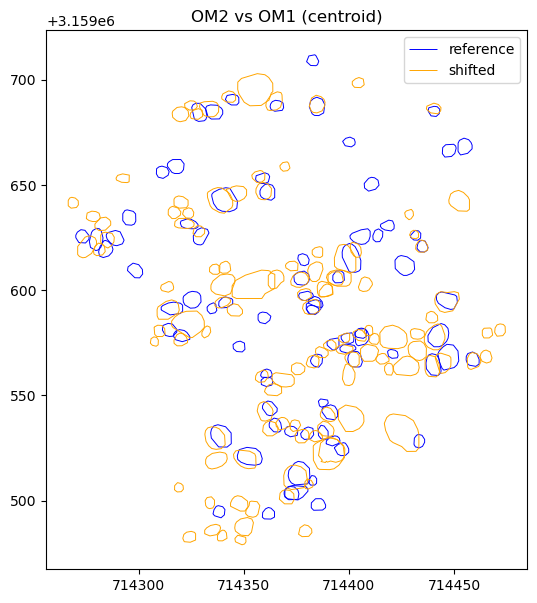

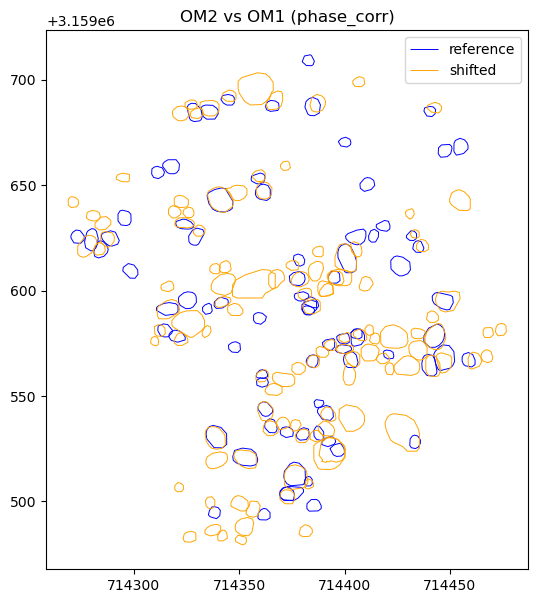

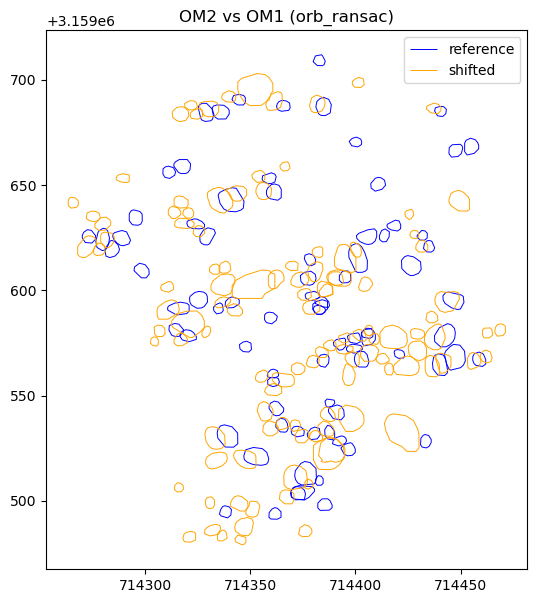

In [25]:
def apply_shift_gdf(gdf: gpd.GeoDataFrame, dx: float, dy: float) -> gpd.GeoDataFrame:
    gdf2 = gdf.copy()
    gdf2['geometry'] = gdf2['geometry'].apply(lambda g: translate(g, xoff=dx, yoff=dy))
    return gdf2

def plot_crown_overlay(ref_gdf, mov_gdf, title=''):
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ref_gdf.boundary.plot(ax=ax, color='blue', linewidth=0.7, label='reference')
    mov_gdf.boundary.plot(ax=ax, color='orange', linewidth=0.7, label='shifted')
    ax.set_title(title)
    ax.legend()
    ax.set_aspect('equal')
    plt.show()

# ---- Choose an OM to visualize ----
OM_TO_PREVIEW = [oid for oid in om_ids if oid != ref_id][0] if len(om_ids) > 1 else ref_id

for m in methods:
    dx, dy = shift_results[m][OM_TO_PREVIEW]
    shifted = apply_shift_gdf(crowns_gdfs[OM_TO_PREVIEW], dx, dy)
    plot_crown_overlay(ref_gdf, shifted, title=f'OM{OM_TO_PREVIEW} vs OM{ref_id} ({m})')

In [ ]:
def shift_image_for_overlay(mov_rgb: np.ndarray, shift_row: float, shift_col: float):
    if not SKIMAGE_AVAILABLE:
        return None
    tform = SimilarityTransform(translation=(shift_col, shift_row))
    warped = warp(mov_rgb, tform.inverse, preserve_range=True, order=1)
    return np.clip(warped, 0, 1)

def plot_ortho_overlay(ref_rgb: np.ndarray, mov_rgb: np.ndarray, shift_px: Tuple[float, float], title=''):
    if not SKIMAGE_AVAILABLE:
        print('scikit-image required for image overlays')
        return
    shift_row, shift_col = shift_px
    mov_warped = shift_image_for_overlay(mov_rgb, shift_row, shift_col)
    if mov_warped is None:
        return
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(ref_rgb)
    ax.imshow(mov_warped, alpha=0.5)
    ax.set_title(title)
    ax.axis('off')
    plt.show()

if ref_gray is not None and ortho_rgb.get(OM_TO_PREVIEW) is not None:
    ref_rgb = ortho_rgb[ref_id]
    mov_rgb = ortho_rgb[OM_TO_PREVIEW]
    # Phase correlation overlay (uses pixel shift directly)
    if 'shift_px' in meta_results['phase_corr'][OM_TO_PREVIEW]:
        plot_ortho_overlay(ref_rgb, mov_rgb, meta_results['phase_corr'][OM_TO_PREVIEW]['shift_px'], title=f'Ortho overlay OM{OM_TO_PREVIEW} phase_corr')
    # ORB overlay (uses pixel shift directly)
    if 'shift_px' in meta_results['orb_ransac'][OM_TO_PREVIEW]:
        plot_ortho_overlay(ref_rgb, mov_rgb, meta_results['orb_ransac'][OM_TO_PREVIEW]['shift_px'], title=f'Ortho overlay OM{OM_TO_PREVIEW} orb_ransac')
    # Centroid method overlay (convert dx/dy to pixel shift)
    if ref_transform is not None:
        dx, dy = shift_results['centroid'][OM_TO_PREVIEW]
        shift_col = dx / ref_transform.a
        shift_row = dy / ref_transform.e
        plot_ortho_overlay(ref_rgb, mov_rgb, (shift_row, shift_col), title=f'Ortho overlay OM{OM_TO_PREVIEW} centroid')

## Notes
- If the ORB or phase correlation methods fail, check the printed metadata in `meta_results` to see if there were insufficient matches or missing orthos.
- If needed, increase `MAX_PREVIEW_SIZE` or adjust ORB thresholds to improve feature matching.
- Once you choose a shift strategy, we can wire it back into the full tracking pipeline.